# Portfolio Metrics

In [545]:
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import date, timedelta
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import seaborn as sns
import contextlib
import io
from copulae import GaussianCopula, StudentCopula
from scipy.stats import t as student_t, norm, laplace, genextreme

In [546]:
q = {
    "VEA":43, 
    "META":2, 
    "MSFT":3, 
    "JPM":4, 
    "SPY":42, 
}

tickers = list(q.keys())

years = 10
end_date = date.today()
start_date = end_date - timedelta(days=years * 365)

In [547]:
def get_data(symbols, start_date, end_date, interval="1d"):
    """
    Fetch OHLCV data from Yahoo Finance using yfinance.

    Returns:
        data: long DataFrame with columns:
              symbol, open, high, low, close, adj_close, volume
        close_prices: wide DataFrame of close prices by symbol
    """

    raw = yf.download(
        tickers=symbols,
        start=start_date.isoformat(),
        end=end_date.isoformat(),
        interval=interval,
        auto_adjust=False,
        group_by="ticker",
        progress=True,
        threads=True
    )

    all_dfs = []

    for symbol in symbols:
        try:
            df = raw[symbol].copy()
        except KeyError:
            print(f"No data returned for {symbol}")
            continue

        if df.empty:
            print(f"No data returned for {symbol}")
            continue

        df = df.rename(columns={
            "Open": "open",
            "High": "high",
            "Low": "low",
            "Close": "close",
            "Adj Close": "adj_close",
            "Volume": "volume"
        })

        df["symbol"] = symbol
        df.index.name = "timestamp"

        df = df[["symbol", "open", "high", "low", "close", "adj_close", "volume"]]
        all_dfs.append(df)

    data = pd.concat(all_dfs).sort_index()

    close_prices = data.pivot_table(
        values="close",
        index=data.index,
        columns="symbol"
    )

    return data, close_prices


In [548]:
data, close_prices = get_data(tickers, start_date, end_date, interval="1mo")

print(close_prices.tail())

[*********************100%***********************]  5 of 5 completed

symbol             JPM        META        MSFT         SPY        VEA
timestamp                                                            
2026-03-01  294.160004  572.130005  370.170013  650.340027  64.080002
2026-04-01  313.230011  611.909973  407.779999  718.659973  68.800003
2026-05-01  299.309998  632.510010  450.239990  756.479980  71.769997
2026-06-01  327.329987  563.289978  373.019989  746.770020  71.250000
2026-07-01  336.470001  669.210022  385.100006  754.950012  70.989998


## Testing out the `Portfolio` class 

In [549]:
from portfolio import Portfolio

In [550]:
# weights of each holding
w = {k: v/sum(q.values()) for k, v in q.items()}

# tickers and price data
my_pft = list(w.keys())
my_prices = close_prices[my_pft]


# create instance of Portfolio class
p = Portfolio(tickers=my_pft, df=my_prices, weights=w, interval="1mo")

In [551]:
w

{'VEA': 0.4574468085106383,
 'META': 0.02127659574468085,
 'MSFT': 0.031914893617021274,
 'JPM': 0.0425531914893617,
 'SPY': 0.44680851063829785}

In [552]:
summary = p.uni_summary()
summary

symbol,VEA,META,MSFT,JPM,SPY
Mean (Ann.),0.065764,0.168289,0.191840,0.161988,0.125547
Volatility (Ann.),0.157554,0.364023,0.213292,0.239185,0.155490
Skew,-0.612218,-0.699266,-0.292788,-0.448517,-0.609815
Kurtosis (Excess),1.704753,2.358834,0.313333,1.449074,0.882752
VaR(5.0%),-0.071218,-0.126636,-0.079280,-0.091401,-0.072695
ES(5.0%),-0.107692,-0.238013,-0.117502,-0.150731,-0.100508
MaxDD,-0.322268,-0.810783,-0.332297,-0.408825,-0.263922


#### Need to adapt uni_summary() method to..
- take into account interval of data (i.e. make it work with monthly/annual data not just daily)
- show portfolio sample stats as well (and hence change name from uni_summary() to just summary or something)

<Axes: title={'center': 'Individual Returns (Daily)'}, xlabel='Date', ylabel='Return (%)'>

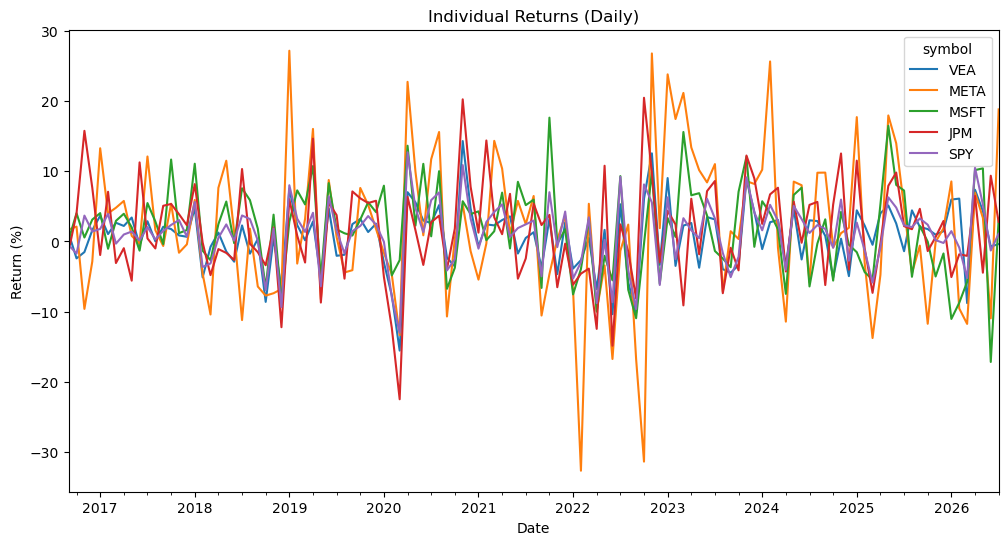

In [553]:
(p.returns(holding='all', log=False)*100).plot(
    title="Individual Returns (Daily)",
    xlabel="Date",
    ylabel="Return (%)",
    figsize=(12, 6)
)

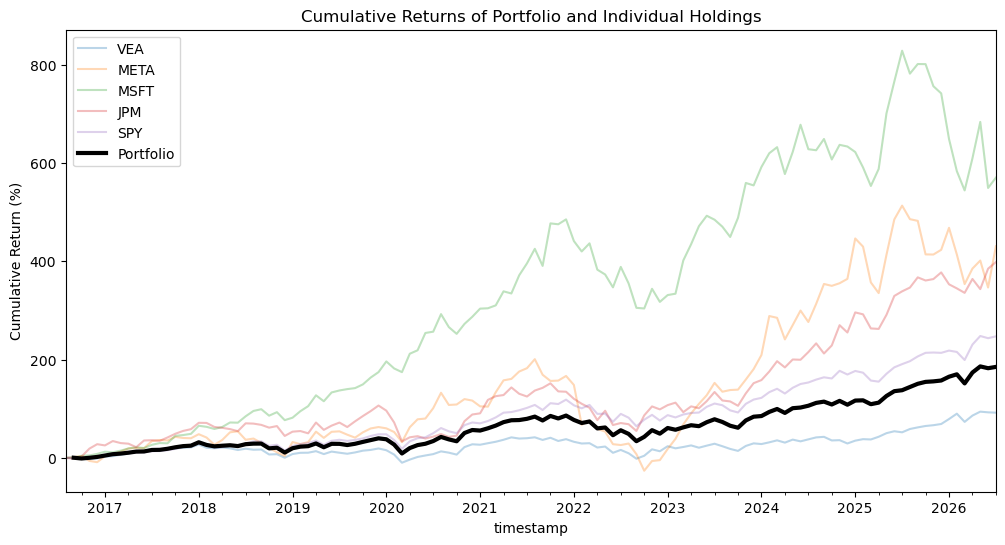

In [554]:
cum_rets = p.data.apply(lambda x: 100*(x/x.iloc[0]-1))

w = p.weights
portfolio_returns = p.returns(log=False).dot(
    np.array([w[t] for t in p.data.columns])
)

portfolio_cumulative = ((1 + portfolio_returns).cumprod() - 1) * 100

ax = cum_rets.plot(
    title="Cumulative Returns of Portfolio and Individual Holdings",
    xlabel="Date",
    ylabel="Cumulative Return (%)",
    alpha=0.3,
    figsize=(12, 6),
    legend=True
)

portfolio_cumulative.plot(
    ax=ax,
    linewidth=3,
    color="black",
    label="Portfolio"
)

plt.legend()
plt.show()

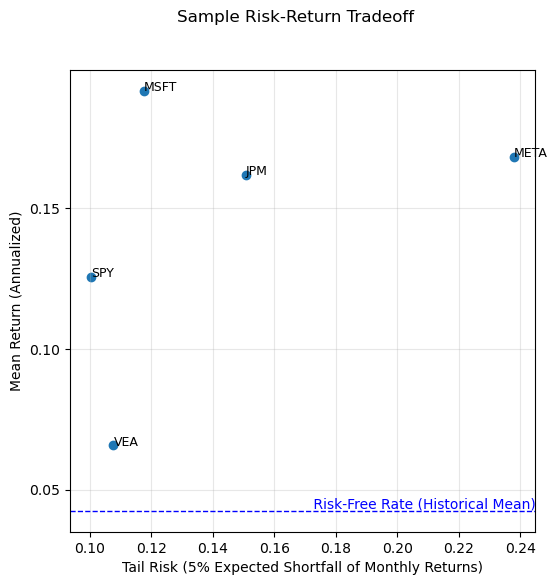

In [555]:
## make this plot a method in the class
fig, ax = plt.subplots(figsize=(6, 6))
x = -summary.loc['ES(5.0%)'] 
y = summary.loc['Mean (Ann.)']
ax.scatter(x=x, y=y)
texts = []
for col in summary.columns:
    texts.append(ax.text(x[col], y[col], col, fontsize=9))
ax.set_xlabel('Tail Risk (5% Expected Shortfall of Monthly Returns)') ; ax.set_ylabel('Mean Return (Annualized)')
fig.suptitle(f'Sample Risk-Return Tradeoff')
ax.grid(True, alpha=0.3)
rf = 0.0425 # historical avg risk-free rate (10yr treasury YTM)
ax.axhline(y=rf, color='blue', linestyle='--', linewidth=1)
ax.text(
    ax.get_xlim()[1],
    rf,
    " Risk-Free Rate (Historical Mean)",
    color="blue",
    va="bottom",
    ha="right",
    fontsize=10
)
ax = plt.gca()
ax.yaxis.set_major_locator(MultipleLocator(0.05))

plt.show()


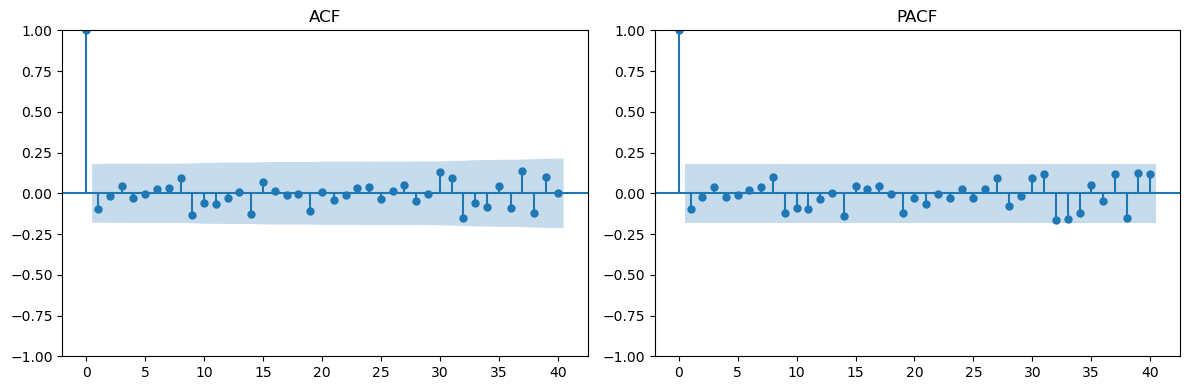

In [556]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF and PACF for returns
log_returns = p.returns(log=True).dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_acf(log_returns.iloc[:, 0], lags=40, ax=axes[0])
axes[0].set_title('ACF')

plot_pacf(log_returns.iloc[:, 0], lags=40, ax=axes[1])
axes[1].set_title('PACF')

plt.tight_layout()
plt.show()

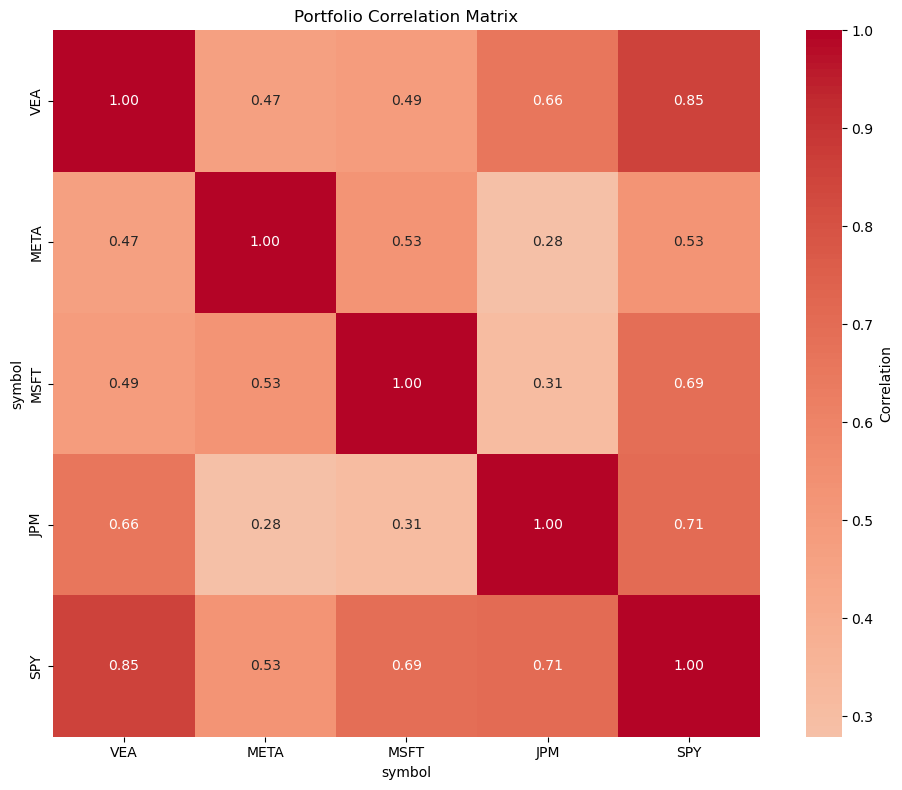

In [557]:
corr_matrix = p.dependence()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, cbar_kws={'label': 'Correlation'})
plt.title('Portfolio Correlation Matrix')
plt.tight_layout()
plt.show()

In [558]:
fit = p.copula_fit(criterion="aic") # note: this can take a couple minutes for the student-t copula

In [559]:
fit["summary"]

,family,loglik,n_params,aic,bic,params,error
0,student_t,183.861663,11,-345.723326,-315.152967,"{'df': 6.069956000849269, 'rho': [0.5257332283...",None
1,gaussian,175.190315,10,-330.380629,-302.589394,"{'rho': [0.5297915743693314, 0.499510131865033...",None


In [560]:
margins = p.margin_fit()

From Sklar's theorem, for a random $d$-vector $X=(X_1,\dots,X_d)^\top$ with joint CDF $F$, copula $C$, and margins $F_i$ for $X_i$, the CDF can be decomposed into
$$
F(x) = C\Big(F_1(x_1),\dots,F_d(x_d) \Big) \quad \forall x\in\mathbb{R}^d
$$
and hence the density $f$ satisfies
$$
f(x) = {\small \frac{d}{dx}} F(x) =  c\Big(F_1(x_1),\dots,F_d(x_d)\Big) \prod_{i=1}^d f_i(x_i) \quad \forall x\in\mathbb{R}^d
$$
where $c$ is the density of the copula, i.e., 
$$ 
c(u) = {\small \frac{\partial^d}{\partial u_1 \cdots \partial u_d }} C(u)
$$

The $t$ copula with $\nu>0$ degrees of freedom and correlation matrix $P\in\mathbb{R}^{d\times d}$ can be represented by
$$
C^t_{\nu, P}(u) = \int_{-\infty}^{t^{-1}_\nu(u_1)} \cdots \int_{-\infty}^{t^{-1}_\nu(u_d)} \frac{\Gamma(\frac{\nu + d}{2})}{\Gamma(\nu/2) \sqrt{(\pi\nu)^d \det P}} 
\Big(1 + \frac{1}{\nu} x^\top P^{-1} x \Big)^{-(\nu + d)/{2}} dx \quad\quad \forall u\in(0,1)^d
$$
where $t^{-1}_\nu$ is the quantile function of a univariate $t_{(\nu)}$ distribution. 

Source: ("The $t$ Copula and Related Copulas") https://www.ressources-actuarielles.net/EXT/ISFA/1226.nsf/0/303eb11b4d617b79c1257b0800744575/$FILE/t%20copula%20demarta%20mcneil.pdf

Let $R=w^\top X$ be the portfolio return random variable, where $w\in[0,1]^d$ is the vector of (fixed) portfolio weights.

The CDF is of $R$ is then 
$$
\begin{aligned}
G(r) &= \mathbb{P}(R\leq r) = \int_{\{x\in\mathbb{R}^d : w^\top x \leq r \}} f(x)dx = \int_{\mathbb{R}^d} \textbf{1}_{\{x\in\mathbb{R}^d : w^\top x \leq r \}} f(x) dx \\
&= \int_{\mathbb{R}^d} \textbf{1}_{\{x\in\mathbb{R}^d : w^\top x \leq r \}} c\Big(F_1(x_1),\dots,F_d(x_d)\Big) \prod_{i=1}^d f_i(x_i) dx
\end{aligned}
$$


In [561]:
simulate = p.joint_simulator()

Let $F_R$ be the CDF of the continuous random variable $R$.
$$
\text{VaR}_\alpha(R) = F_R^{-1}(\alpha)
$$
$$
\text{ES}_\alpha(R)=\mathbb{E}[R\mid R \leq \text{VaR}_\alpha(R)]
$$

Monte Carlo estimate of ES(1.00%) is -13.11% with 95% CI: (-13.1106%, -13.1104%)
Standard Error of ES estimate: 0.000030%


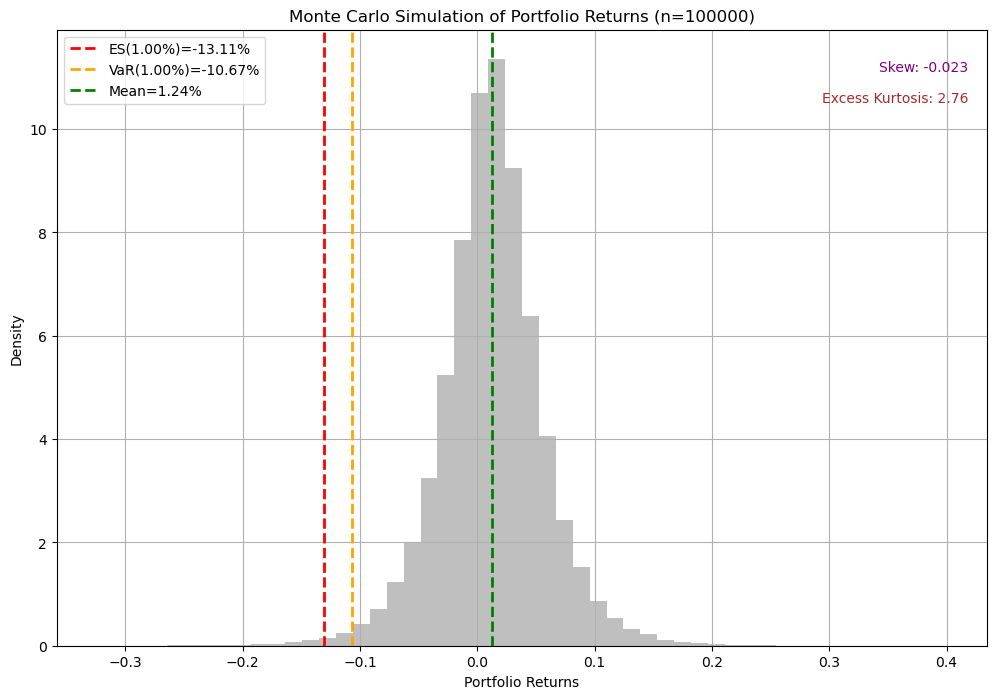

In [562]:
monte_carlo_es = p.monte_carlo_ES(n_samples=int(1e5), alpha=0.01)

- This is from *daily* returns. For monthly estimates, would need to use monthly data.

log return should be approx equal to simple return (follows from Taylor expansion of ln(1+x) )

### `SimReturnsVector()`
1. Simulate $V\sim C$ via $V_i=C^{-1}(U_i)$ for $i=1,\dots,d$ where $U\overset{iid}{\sim}\text{Unif}(0,1)$
2. Simulate and return $X\sim F$ via $X_i=F_i^{-1}(V_i)$ for $i=1,\dots,d$

### `SimPortfolioReturn()`
1. Simulate $X=$`SimReturnsVector()`
2. Return $R=w^\top X$

### `SimShortfall()`
1. Simulate $R=$`SimPortfolioReturn()`
2. If $R\leq \text{VaR}_\alpha(R)$, (accept the sample) return $R$. Otherwise, return None (skip to next sample)

## Next Features for this Project

AFTER FINISHING MIT FACTOR MODELING STUDYING:
- linear factor models
    - understanding portfolio risks/drivers
    - parameter reduction for covariance estimation
    - stress testing (e.g. VaR / ES under different macro shock/equity market scenarios)
- do the same as above but with *neural nets* instead of linear factor model
- portfolio optimization
    - Mean-Var optimiziation (with different covariance matrix estimates incl. the factor model est.)
    - Mean-ES optimization
- volatility models
    - GARCH (+ dynamic mean return model -- look for examples online of what ppl use / look at Mike M's PhD paper)
    - Stochastic Vol model (Heston) - which also models returns as a whole
    - VaR / ES forecasting from the model
- genAI feature(s): 
    - RAG over market news for explaining recent portfolio movements

SEPARATE PROJECT:
- market bubble / market crash predictor
    - can try a variety of methods and/or an ensemble of them
        - the graph theory one or whatever from algebraic continuation channel,
        - the XLU/SPY z-score thiing or whatever from iPhone notes on PROJECTS

### Next: do ES-based portfolio optimization (e.g. using `cvxpy`) and test out/make portfolio-wide summaries

- Review portfolio optimization math
    - CS 335 chapter 
    - ACTSC 372 chapter 
    - CO 372

Need to use weights not quantities. Also, we have to make an assumption about dynamic rebalancing right?

### Some Plotting (make this a method)

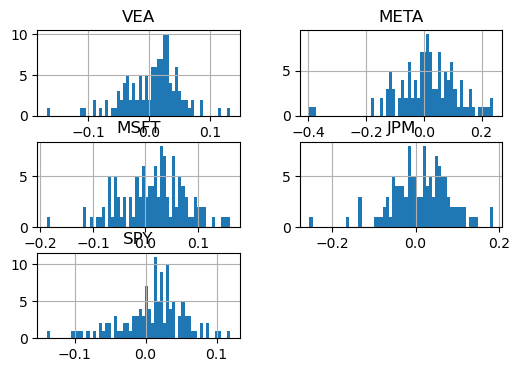

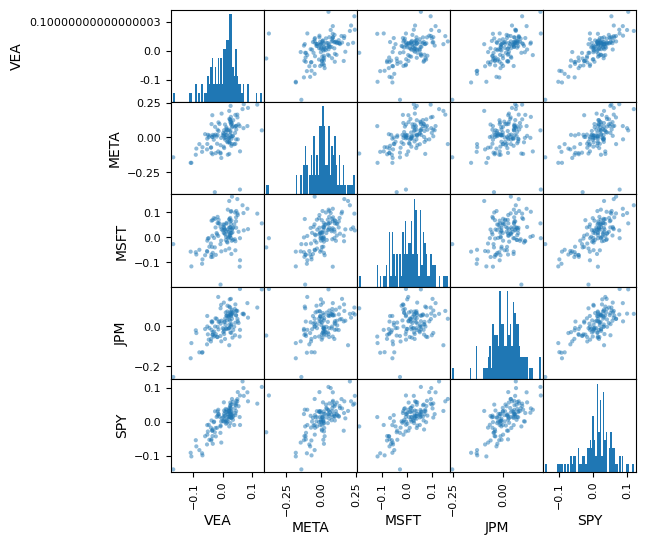

In [563]:
# histogram of returns of each holding
log_returns = p.returns(log=True)
log_returns.hist(bins=60, figsize=(6,4))
plt.show()

# scatterplot matrix of portfolio returns
pd.plotting.scatter_matrix(log_returns, figsize=(6,6), hist_kwds={'bins':60})
plt.show()

### Another Project: make+test index arbitrage strategy taking advantage of strong correlation between VEA and SPY (and likely many common holdings)